## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np
import pandas as pd

project_path = 'G:\\Mi unidad\\Tesis v1\\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)



#Rutas donde tenemos demás recursos
scripts_path = os.path.join(project_path, 'scripts')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1\Movement_clasify
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [2]:
"""            
            0: FULL           
            1: SOLO MOTOR (5 clases)
            2: SOLO IMAGINADO 5 CLASES
            3: 9 CLASES SIN FUSIÓN
            4: REST-IZQ-DER fusionado
            5: REST-MANOS-PIES fusionado
            6: REST-IZQ-DER SOLO MOTOR
            7: REST-MANOS-PIES SOLO MOTOR
            8: TODAS CLASES BINARIO (REST vs MOVIMIENTO)
            9: REST vs MOVIMIENTO SOLO MOTOR
            10: MANOS VS PIES, fusionado
            11: MANOS VS PIES, solo motor
            12: DERECHA vs IZQUIERDA, fusionado 
            13: DERECHA vs IZQUIERDA, solo motor
            14: IZQ-DER-MANO-PIES FUSIONADAS
            15: IZQ-DER-MANO-PIES SOLO MOTOR
            16: REST-IZQ-DER IMAGINADO
            17: REST-MANOS-PIES IMAGINAGO 
            18: REST-RIGHT-FEET IMAGINADO MOABB
"""

#Probamos nuestro nuevo objeto
pick = 6
train = dl.Selection(pick=pick)
fine = dl.Selection(pick=pick)
test = dl.Selection(pick=pick)


### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [3]:
path_train = "Recursos/v2/train/eeg_dataset_7_ch_0.00015rate.npz"
path_fine = "Recursos/v2/fine/eeg_dataset_7_ch_0.00015rate.npz"
path_test = "Recursos/v2/test_2/eeg_dataset_7_ch_1rate.npz"


train.load(path_train)
#train.pick_ch(["C3..", "C4..", "Cz.."])

fine.load(path_fine)
#fine.pick_ch(["C3..", "C4..", "Cz.."])

test.load(path_test)
#test.pick_ch(["C3..", "C4..", "Cz.."])
channels = len(train.X[0])


✔️ Dataset cargado desde: Recursos/v2/train/eeg_dataset_7_ch_0.00015rate.npz
✔️ Dataset cargado desde: Recursos/v2/fine/eeg_dataset_7_ch_0.00015rate.npz
✔️ Dataset cargado desde: Recursos/v2/test_2/eeg_dataset_7_ch_1rate.npz


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [4]:
train.pipeline()


fine.pipeline()


test.pipeline()



### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [5]:
print("Datos del train:")
train.resume_data()

print("Datos del dataset de finetunnning:")
fine.resume_data()

print("Datos del dataset del test:")
test.resume_data()

Datos del train:
X shape: (40865, 7, 160)
y shape: (40865,)
sub shape: (40865,)
trial shape: (40865,)
run shape: (40865,)
Número de clases: 3
Número de sujetos: 95

Clases:
   codigo   nombre
0       0     rest
1       1  right_m
2       2   left_m

Conteo por clase:
0    20280
1    10245
2    10340
Name: count, dtype: int64
Datos del dataset de finetunnning:
X shape: (2250, 7, 160)
y shape: (2250,)
sub shape: (2250,)
trial shape: (2250,)
run shape: (2250,)
Número de clases: 3
Número de sujetos: 5

Clases:
   codigo   nombre
0       0     rest
1       1  right_m
2       2   left_m

Conteo por clase:
0    1125
1     555
2     570
Name: count, dtype: int64
Datos del dataset del test:
X shape: (2250, 7, 160)
y shape: (2250,)
sub shape: (2250,)
trial shape: (2250,)
run shape: (2250,)
Número de clases: 3
Número de sujetos: 5

Clases:
   codigo   nombre
0       0     rest
1       1  right_m
2       2   left_m

Conteo por clase:
0    1125
1     555
2     570
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [5]:
data_fine_folds, data_test_folds, fold_table = dl.runfolds(
    fine_obj=fine,
    test_obj=test,
    debug = False
)

fold_table





,fold,subject,test_run,fine_runs,test_runs,n_fine,n_test,fine_class_counts,test_class_counts,fine_modes,test_modes
0,0,7,3,"[np.int32(7), np.int32(11)]",[np.int32(3)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
1,1,7,7,"[np.int32(3), np.int32(11)]",[np.int32(7)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
2,2,7,11,"[np.int32(3), np.int32(7)]",[np.int32(11)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
3,3,31,3,"[np.int32(7), np.int32(11)]",[np.int32(3)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
4,4,31,7,"[np.int32(3), np.int32(11)]",[np.int32(7)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
5,5,31,11,"[np.int32(3), np.int32(7)]",[np.int32(11)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
6,6,50,3,"[np.int32(7), np.int32(11)]",[np.int32(3)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
7,7,50,7,"[np.int32(3), np.int32(11)]",[np.int32(7)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
8,8,50,11,"[np.int32(3), np.int32(7)]",[np.int32(11)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]
9,9,67,3,"[np.int32(7), np.int32(11)]",[np.int32(3)],300,150,"{np.int32(0): np.int64(150), np.int32(1): np.i...","{np.int32(0): np.int64(75), np.int32(1): np.in...",[np.str_('LR_M')],[np.str_('LR_M')]


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

In [ ]:


modelo, history, mean, std, keras_split, sorted_test, info = dl.eeg_train(
    train, val_size=0.20, undersample_rest=False, use_class_weight=True,
    mode="run", make_test=False, test_run=data_test_folds, dynamic_lr = False,
    epochs=60, patience_level='medium',
    Lr=1e-4,  dropout_rate=0.25, batch = 32, apply_lsf=True, apply_ea= True,
    debug=False
)

dl.plot_history(history, lr_schedule=info["Lr_grid"], best_epoch = info["best_epoch"])


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### Examinar modelo obtenido

In [ ]:


df_sub, df_runs_raw, rows_raw = dl.evaluate_moabb(
    modelo,
    test_subsets=data_test_folds,
    mean=mean,
    std=std,
    label_map=train.label_map,
    test_result="subject"
)

path_csv = f"Recursos/models/general/v4/{pick}_mode/{channels}_ch"

if not os.path.exists(path_csv):
    os.makedirs(path_csv)


df_sub.to_csv(f"{path_csv}/EEG_generalmetrics_moderun_slf_ea.csv")
df_sub

,subject,run,fined,accuracy,macro_f1,balanced_accuracy,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std
0,67,all,all folds,0.504 ± 0.010,0.250 ± 0.036,0.344 ± 0.017,0.504,0.010,0.250,0.036,0.344,0.017
1,31,all,all folds,0.504 ± 0.008,0.238 ± 0.027,0.340 ± 0.012,0.504,0.008,0.238,0.027,0.340,0.012
2,7,all,all folds,0.500 ± 0.000,0.222 ± 0.000,0.333 ± 0.000,0.500,0.000,0.222,0.000,0.333,0.000
3,50,all,all folds,0.500 ± 0.000,0.222 ± 0.000,0.333 ± 0.000,0.500,0.000,0.222,0.000,0.333,0.000
4,98,all,all folds,0.500 ± 0.000,0.222 ± 0.000,0.333 ± 0.000,0.500,0.000,0.222,0.000,0.333,0.000


In [ ]:
#Guardamos el modelo y sus parámetros de normalización

channels = len(train.X[0])

path = f"Recursos/models/general/v4/{pick}_mode/{channels}_ch"

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(
    model=modelo,
    mean=mean,
    std=std,
    label_map=test.label_map,
    path=path,

    name=f"EEGNet_model_run_slf_ea"
)



Modelo guardado    : Recursos/models/general/v4/6_mode/7_ch\EEGNet_model_run_slf.keras
Parámetros guardados: Recursos/models/general/v4/6_mode/7_ch\EEGNet_model_run_slf.npz
Clases del modelo  : {0: np.str_('rest'), 1: np.str_('right_m'), 2: np.str_('left_m')}
EA incluida        : No


In [7]:
modelo, mean, std = dl.load_model(model_path=f"Recursos/models/general/v4/6_mode/7_ch/EEGNet_model_run_slf.keras", 
                                  params_path=f"Recursos/models/general/v4/6_mode/7_ch/EEGNet_model_run_slf.npz"
)


Fold 1/15 | subject=7 | test_run=3
[Fine-tune] Validation loss=0.7706, acc=0.6467

Fold 2/15 | subject=7 | test_run=7
[Fine-tune] Validation loss=0.5191, acc=0.7600

Fold 3/15 | subject=7 | test_run=11
[Fine-tune] Validation loss=0.6135, acc=0.7467

Fold 4/15 | subject=31 | test_run=3
[Fine-tune] Validation loss=1.1311, acc=0.5733

Fold 5/15 | subject=31 | test_run=7
[Fine-tune] Validation loss=0.7795, acc=0.6333

Fold 6/15 | subject=31 | test_run=11
[Fine-tune] Validation loss=0.7875, acc=0.6867

Fold 7/15 | subject=50 | test_run=3
[Fine-tune] Validation loss=1.1001, acc=0.4600

Fold 8/15 | subject=50 | test_run=7
[Fine-tune] Validation loss=0.7298, acc=0.6200

Fold 9/15 | subject=50 | test_run=11
[Fine-tune] Validation loss=1.0388, acc=0.5867

Fold 10/15 | subject=67 | test_run=3
[Fine-tune] Validation loss=1.2897, acc=0.3800

Fold 11/15 | subject=67 | test_run=7
[Fine-tune] Validation loss=0.8651, acc=0.4933

Fold 12/15 | subject=67 | test_run=11
[Fine-tune] Validation loss=0.9026,

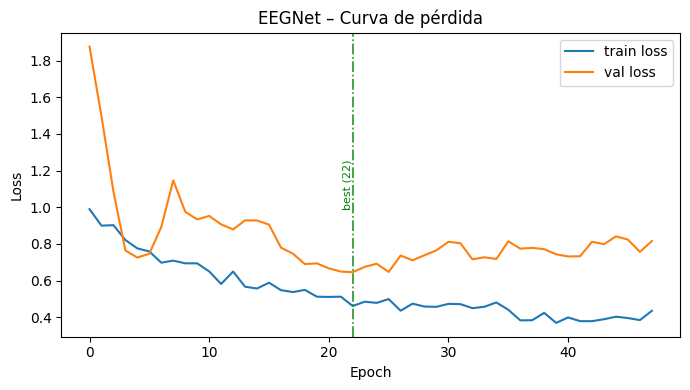

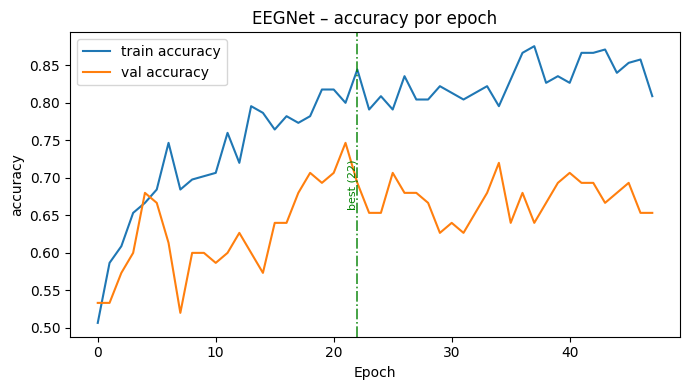


 EVALUACIÓN Mejor fold - test run 7

[Métricas globales]
Accuracy                  : 0.7600
Balanced accuracy         : 0.7694
Macro precision           : 0.7490
Macro recall              : 0.7694
Macro F1                  : 0.7559
Weighted F1               : 0.7615
Cohen's kappa             : 0.6242
Matthews corrcoef         : 0.6271
Log loss                  : 0.5191
ROC-AUC macro             : 0.9235
Chance level              : 0.3333
Accuracy over chance norm : 0.6400

[Clases]
  0: rest
  1: right_m
  2: left_m

[Reporte de clasificación]
              precision    recall  f1-score   support

        rest       0.82      0.73      0.77        75
     right_m       0.65      0.80      0.72        35
      left_m       0.78      0.78      0.78        40

    accuracy                           0.76       150
   macro avg       0.75      0.77      0.76       150
weighted avg       0.77      0.76      0.76       150


[Interpretación rápida]
- Accuracy: rendimiento global.
- Balanced 

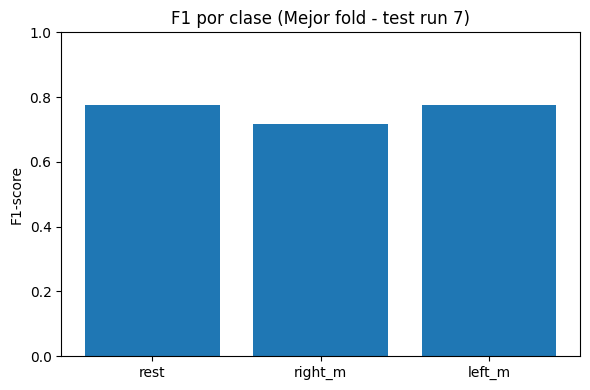

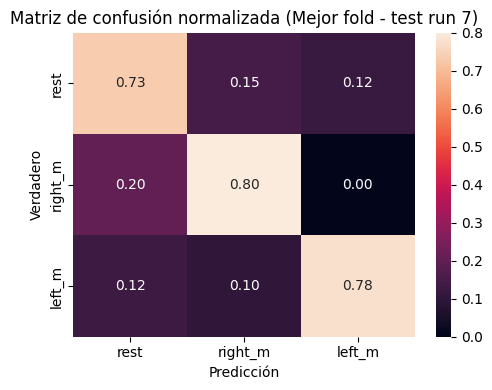

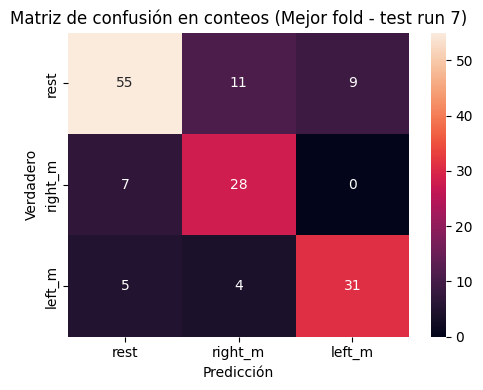

,subject,run,fined,accuracy,macro_f1,balanced_accuracy,accuracy_mean,macro_f1_mean,balanced_accuracy_mean
0,7,all,all folds,0.718 ± 0.062,0.681 ± 0.084,0.687 ± 0.089,0.718,0.681,0.687
1,31,all,all folds,0.631 ± 0.057,0.551 ± 0.087,0.555 ± 0.081,0.631,0.551,0.555
2,98,all,all folds,0.587 ± 0.035,0.483 ± 0.082,0.501 ± 0.067,0.587,0.483,0.501
3,50,all,all folds,0.556 ± 0.084,0.436 ± 0.023,0.480 ± 0.033,0.556,0.436,0.480
4,67,all,all folds,0.476 ± 0.088,0.383 ± 0.064,0.409 ± 0.048,0.476,0.383,0.409


In [ ]:
rows = []

models_ft = []
histories_ft = []
splits_ft = []
infos_ft = []
metrics_ft = []
means_ft = []
stds_ft = []
ea_matrices = []


for i in range(len(data_fine_folds)):

    subject_i = fold_table.loc[i, "subject"]
    test_run_i = fold_table.loc[i, "test_run"]

    print("\n" + "=" * 70)
    print(f"Fold {i+1}/{len(data_fine_folds)} | subject={subject_i} | test_run={test_run_i}")
    print("=" * 70)

    modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft, info_ft, ea_matrix = dl.eeg_fine(modelo, data_fine_folds[i], mean = None, std = None, test_size=0.15, val_size=0.25,
                                                                                make_test=False, test_run=data_test_folds[i], undersample_rest = False, normalize = False,
                                                                                debug=False, epochs=200, lr=4e-3, batch_size=16, unfreeze_last_n=64, monitor = 'val_loss',
                                                                                dynamic_lr=False,use_class_weight = True, patience_level='high',
                                                                                apply_lsf=False, apply_ea = True)
    
    metrics = dl.evaluate(
        modelo_ft, keras_split_ft, label_map=test.label_map,
        title=f"Fine-tuning  N° {i}", plot=False, verbose=False
    )

    row = {
        "fold": i,
        "subject": subject_i,
        "test_run": int(np.unique(data_test_folds[i].run)[0]),
        "fine_runs": str(list(np.unique(data_fine_folds[i].run))),
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "macro_f1": metrics["macro_f1"]
    }

    for name in metrics["class_names"]:
        clean = str(name).replace(" ", "_")
        row[f"f1_{clean}"] = metrics.get(f"f1_{clean}")
        row[f"recall_{clean}"] = metrics.get(f"recall_{clean}")
        row[f"precision_{clean}"] = metrics.get(f"precision_{clean}")

    rows.append(row)

    models_ft.append(modelo_ft)
    means_ft.append(mean_ft)
    stds_ft.append(std_ft)
    histories_ft.append(histor_ft)
    splits_ft.append(keras_split_ft)
    infos_ft.append(info_ft)
    metrics_ft.append(metrics)
    ea_matrices.append(ea_matrix)

df_runfold = pd.DataFrame(rows)

df_runfold = df_runfold.sort_values(
    by=["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False
)

best_fold = int(df_runfold.iloc[0]["fold"])

dl.plot_history(histories_ft[best_fold], best_epoch=infos_ft[best_fold].get("best_epoch"))
dl.evaluate(models_ft[best_fold], splits_ft[best_fold], test.label_map, title=f"Mejor fold - test run {df_runfold.iloc[0]['test_run']}",)

df_ft_sub = dl.summarize_finetuning_by_subject(df_runfold)
df_ft_sub



In [9]:
path = f"Recursos/models/fined/v4/{pick}_mode_finned_model/{channels}_ch"

if not os.path.exists(path):
    os.makedirs(path)

df_ft_sub.to_csv(f"{path}/runfold_moderun_slf.csv", index=False)

In [ ]:

path_f = f"Recursos/models/fined/v4/{pick}_mode_finned_model/{channels}_ch"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(
    model=models_ft[best_fold],
    mean=means_ft[best_fold],
    std=stds_ft[best_fold],
    label_map=test.label_map,
    path=path_f,
    split = splits_ft[best_fold],
    info = infos_ft[best_fold],
    ea_matrix=ea_matrices[best_fold],
    name=f"EEGNet_bestmodel_ft"
    )



Guardando modelo en: Recursos/models/fined/v4/8_mode_finned_model/7_ch
Modelo guardado: Recursos/models/fined/v4/8_mode_finned_model/7_ch\EEGNet_bestmodel_ft.keras
Parámetros guardados: Recursos/models/fined/v4/8_mode_finned_model/7_ch\EEGNet_bestmodel_ft.npz
Clases del modelo: {0: np.str_('rest'), 1: np.str_('no_rest')}


[Intento 1]: Probando con las métricas Lr = 0.0002, monitor = val_loss, batch = 16 y unfreeze = 64
Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.9458, acc=0.4800
🔥 Nuevo mejor modelo: exp 1 | macro_f1=0.4549
Accuracy:          0.4800
Balanced accuracy: 0.5316
Macro F1:          0.4549
[Intento 2]: Probando con las métricas Lr = 0.0002, monitor = val_loss, batch = 16 y unfreeze = 128
Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.9425, acc=0.4867
🔥 Nuevo mejor modelo: exp 2 | macro_f1=0.4613
Accuracy:          0.4867
Balanced accuracy: 0.5360
Macro F1:          0.4613
[Intento 3]: Probando con las métricas Lr = 0.0002, monitor = val_loss, batch = 16 y unfreeze = None
Se realizará evaluación en el set reservado
[Fine-tune] Validation loss=0.9242, acc=0.4867
🔥 Nuevo mejor modelo: exp 3 | macro_f1=0.4652
Accuracy:          0.4867
Balanced accuracy: 0.5348
Macro F1:          0.4652
[Intento 4]: Probando con las métricas Lr = 0.0002, mon

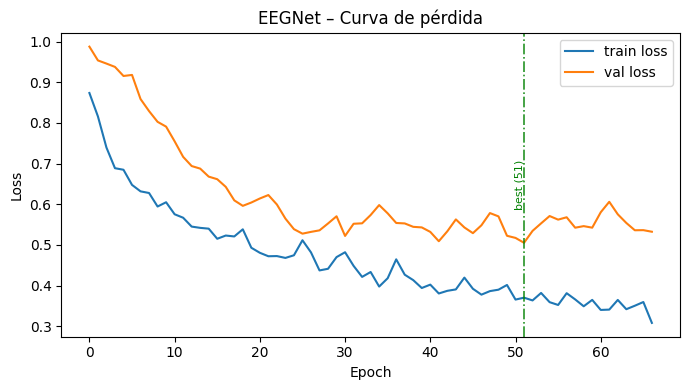

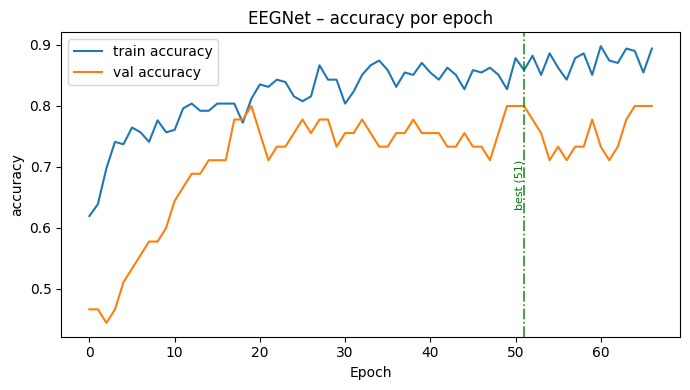

,exp_id,lr,undersample,batch_size,unfreeze_last_n,weight,patience_level,accuracy,balanced_accuracy,macro_f1,weighted_f1,f1_rest,recall_rest,precision_rest,f1_right_m,recall_right_m,precision_right_m,f1_left_m,recall_left_m,precision_left_m
20,21,0.0010,False,16,all,True,high,0.560000,0.604683,0.552713,0.557718,0.581197,0.453333,0.809524,0.475000,0.475,0.475000,0.601942,0.885714,0.455882
25,26,0.0010,False,32,128,True,high,0.560000,0.601984,0.548621,0.559104,0.598291,0.466667,0.833333,0.465753,0.425,0.515152,0.581818,0.914286,0.426667
26,27,0.0010,False,32,all,True,high,0.553333,0.597540,0.542495,0.551384,0.586207,0.453333,0.829268,0.459459,0.425,0.500000,0.581818,0.914286,0.426667
31,32,0.0010,False,8,128,True,high,0.546667,0.586825,0.540045,0.546851,0.571429,0.453333,0.772727,0.493151,0.450,0.545455,0.555556,0.857143,0.410959
30,31,0.0010,False,8,64,True,high,0.560000,0.595397,0.539549,0.556059,0.616667,0.493333,0.822222,0.417910,0.350,0.518519,0.584071,0.942857,0.423077
18,19,0.0010,False,16,64,True,high,0.566667,0.570556,0.537198,0.566021,0.661654,0.586667,0.758621,0.406250,0.325,0.541667,0.543689,0.800000,0.411765
23,24,0.0010,False,8,all,True,high,0.546667,0.558730,0.529941,0.549673,0.615385,0.533333,0.727273,0.438356,0.400,0.484848,0.536082,0.742857,0.419355
21,22,0.0010,False,8,64,True,high,0.533333,0.570159,0.522222,0.531481,0.566667,0.453333,0.755556,0.444444,0.400,0.500000,0.555556,0.857143,0.410959
19,20,0.0010,False,16,128,True,high,0.546667,0.557222,0.520679,0.545241,0.630769,0.546667,0.745455,0.376812,0.325,0.448276,0.554455,0.800000,0.424242
24,25,0.0010,False,32,64,True,high,0.533333,0.566270,0.519577,0.535060,0.588235,0.466667,0.795455,0.434783,0.375,0.517241,0.535714,0.857143,0.389610


In [31]:
#Pequeño grid search para mejores parámetros 

rows = []

Lr_list = [2e-4, 1e-3]
batchs = [16, 8, 32]
unfreeze_list = [64, 128, None]
monitor_list = ['val_loss', 'val_accuracy']
patience = 'high'
dynamic = False
epoch_list = [150]
under = False
epoch=150
weight = True


exp_id = 0

best_score = -np.inf
best_bundle = None

for Lr in Lr_list: 
    for monitor in monitor_list: 
        for batch in batchs:
            for unfreeze in unfreeze_list:

                exp_id += 1

                print(f"[Intento {exp_id}]: Probando con las métricas Lr = {Lr}, monitor = {monitor}, batch = {batch} y unfreeze = {unfreeze}")

                modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft, info_ft = dl.eeg_fine(modelo, data_fine, mean = mean, std = std, test_size=0.15, val_size=0.15,
                                                                        make_test=False, test_run=data_test, undersample_rest = under, monitor = monitor,
                                                                        debug=False, epochs=epoch, lr=Lr, batch_size=batch, unfreeze_last_n=unfreeze, normalize=True,
                                                                        dynamic_lr=dynamic, model_checkpoint=f"checkpoints/ft_exp_{exp_id:03d}.keras")
                
                metrics = dl.evaluate(
                    modelo_ft,
                    keras_split_ft,
                    label_map=obj.label_map,
                    title=f"FT exp {exp_id}",
                    plot=False,
                    verbose=False
                )

            
                row = {
                    "exp_id": exp_id,
                    "lr": Lr,
                    "undersample": under,
                    "batch_size": batch,
                    "unfreeze_last_n": "all" if unfreeze is None else unfreeze,
                    "weight": weight,
                    "patience_level": patience,
                    "accuracy": metrics["accuracy"],
                    "balanced_accuracy": metrics["balanced_accuracy"],
                    "macro_f1": metrics["macro_f1"],
                    "weighted_f1": metrics["weighted_f1"]
                 
                }

                # Métricas por clase
                for name in metrics["class_names"]:
                    clean = str(name).replace(" ", "_")
                    row[f"f1_{clean}"] = metrics.get(f"f1_{clean}")
                    row[f"recall_{clean}"] = metrics.get(f"recall_{clean}")
                    row[f"precision_{clean}"] = metrics.get(f"precision_{clean}")

                    score = metrics["macro_f1"]  # métrica principal para elegir ganador

                if score > best_score:
                    best_score = score

                    best_bundle = {
                        "exp_id": exp_id,
                        "model": modelo_ft,
                        "history": histor_ft,
                        "mean": mean_ft,
                        "std": std_ft,
                        "keras_split": keras_split_ft,
                        "info": info_ft,
                        "metrics": metrics,
                        "params": {
                            "lr": Lr,
                            "batch_size": batch,
                            "unfreeze_last_n": unfreeze,
                            "dynamic": dynamic,
                            "epochs": epoch,
                            "patience_level": patience,
                            "checkpoint_path": f"checkpoints/ft_exp_{exp_id:03d}.keras"
                        }
                         }

                    print(f"🔥 Nuevo mejor modelo: exp {exp_id} | macro_f1={best_score:.4f}")

                rows.append(row)

                print(f"Accuracy:          {metrics['accuracy']:.4f}")
                print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
                print(f"Macro F1:          {metrics['macro_f1']:.4f}")

df_grid_simple = pd.DataFrame(rows)

df_grid_simple = df_grid_simple.sort_values(
    by=["macro_f1", "balanced_accuracy", "accuracy"],
    ascending=False,
    na_position="last"
)

df_grid_simple.to_csv("grid_3_lr_unfreeze_epoch_under.csv", index=False)

df_grid_simple

best_model_ft = best_bundle["model"]
best_history_ft = best_bundle["history"]
best_mean_ft = best_bundle["mean"]
best_std_ft = best_bundle["std"]
best_keras_split_ft = best_bundle["keras_split"]
best_info_ft = best_bundle["info"]
best_metrics_ft = best_bundle["metrics"]
best_params_ft = best_bundle["params"]

print("Mejor experimento:", best_bundle["exp_id"])
print("Mejores parámetros:", best_params_ft)
print("Mejor macro F1:", best_metrics_ft["macro_f1"])

dl.plot_history(best_history_ft, lr_schedule=best_info_ft["Lr_grid"], best_epoch = best_info_ft["best_epoch"] )
df_grid_simple

        


 EVALUACIÓN EEGNet

[Métricas globales]
Accuracy                  : 0.5600
Balanced accuracy         : 0.6047
Macro precision           : 0.5801
Macro recall              : 0.6047
Macro F1                  : 0.5527
Weighted F1               : 0.5577
Cohen's kappa             : 0.3559
Matthews corrcoef         : 0.3831
Log loss                  : 0.8823
ROC-AUC macro             : 0.7944
Chance level              : 0.3333
Accuracy over chance norm : 0.3400

[Clases]
  0: rest
  1: right_m
  2: left_m

[Reporte de clasificación]
              precision    recall  f1-score   support

        rest       0.81      0.45      0.58        75
     right_m       0.47      0.47      0.47        40
      left_m       0.46      0.89      0.60        35

    accuracy                           0.56       150
   macro avg       0.58      0.60      0.55       150
weighted avg       0.64      0.56      0.56       150


[Interpretación rápida]
- Accuracy: rendimiento global.
- Balanced accuracy: accurac

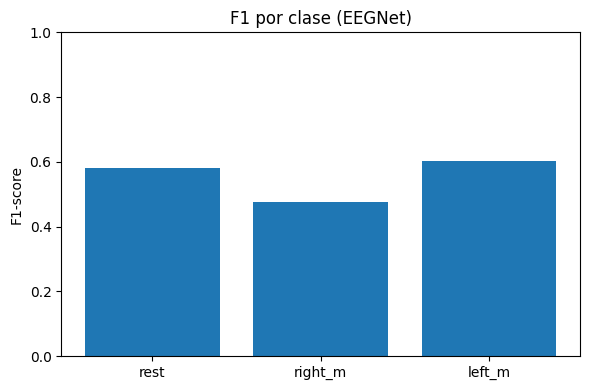

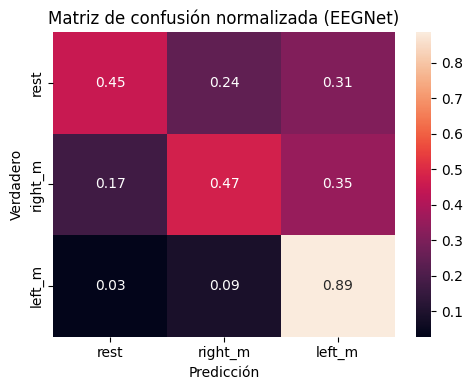

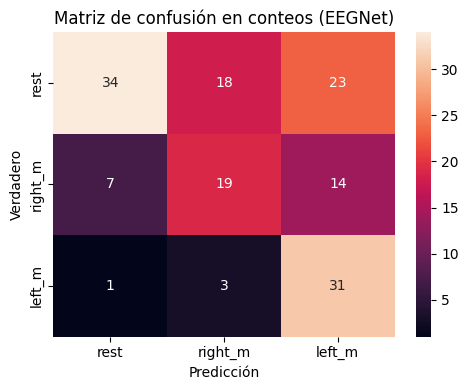

{'title': 'EEGNet',
 'y_true': array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0,
        0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2,
        2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2,
        2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]),
 'y_pred': array([0, 0, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 2, 2, 1, 1, 1,
        1, 0, 0, 1, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 1,
        2, 2, 2, 2, 2, 2, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2,
        2, 2, 2, 2, 1, 1, 2, 0, 0, 1, 2, 1, 1, 0, 2, 2, 2, 2, 0, 2, 2, 2,
        2, 2, 0, 0, 0, 0, 0, 2, 1, 1, 1, 0, 2, 2, 0, 0, 0, 2, 2, 2, 2, 2,
        1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 2,
        

In [32]:
dl.evaluate(best_bundle["model"], best_bundle["keras_split"], obj.label_map)

In [16]:
metrics = dl.compare_models(modelo, models_ft[best_fold], keras_split,  splits_ft[best_fold], obj.label_map)

NameError: name 'keras_split' is not defined